In [65]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import gzip
from scipy.optimize import curve_fit

## 1.

In [66]:
# Parámetros

a = 3 # kpc
b = 0.25*a # kpc
M = 13 # *10^10 M_sun
G = 43007.1

In [67]:
# Potencial

def phi_MN(R,z):
    return -G*M/(R**2+(a+(z**2+b**2)**0.5)**2)**0.5

phi_MN = np.vectorize(phi_MN)

# Densidad

def rho_MN(R,z):
    return (b**2*M/(4*np.pi))*(a*R**2+(a+3*(z**2+b**2)**0.5)*(a+(z**2+b**2)**0.5)**2)/((R**2+(a+(z**2+b**2)**0.5)**2)**2.5*(z**2+b**2)**1.5)

In [68]:
zs = np.linspace(-4*a,4*a,100)
Rs = np.linspace(-6*a,6*a,100)

RR, zz = np.meshgrid(Rs,zs)

Phis = phi_MN(RR,zz)

zsp = np.linspace(-4*a,4*a,1000)
Rsp = np.linspace(-6*a,6*a,1000)

RRp, zzp = np.meshgrid(Rsp,zsp)

rhos = rho_MN(RRp,zzp)

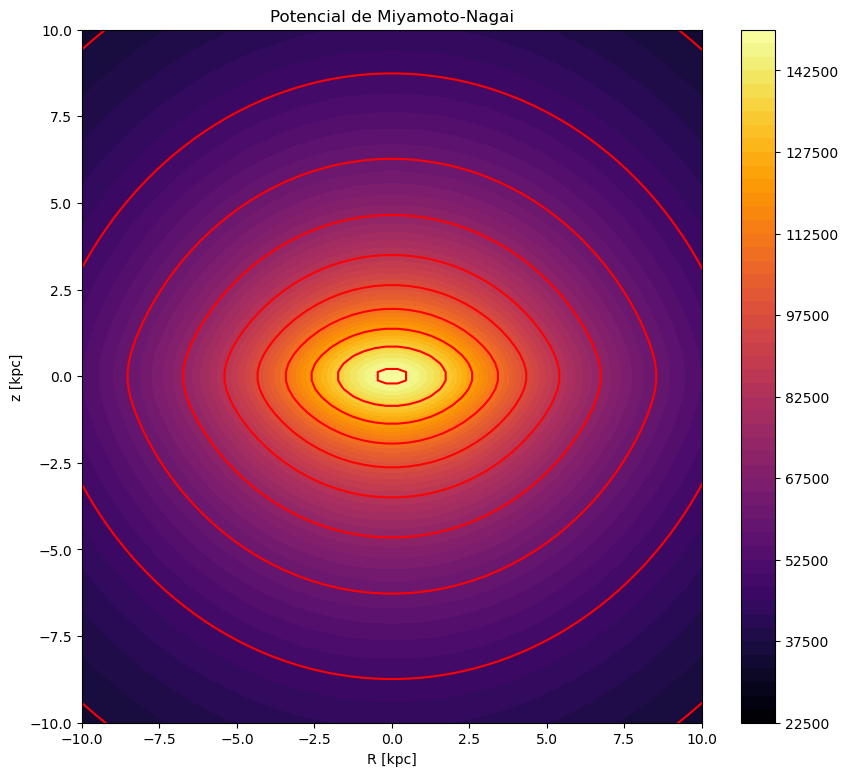

In [69]:
fig, ax = plt.subplots(figsize=(10,9))

CS = ax.contourf(RR,zz,-Phis,cmap='inferno',levels=50)
CS2 = ax.contour(CS, levels=CS.levels[::5], colors='r')
cbar = fig.colorbar(CS)
ax.set(xlim=(-10,10),ylim=(-10,10),xlabel='R [kpc]',ylabel='z [kpc]',title='Potencial de Miyamoto-Nagai')
plt.savefig('potencial.png')

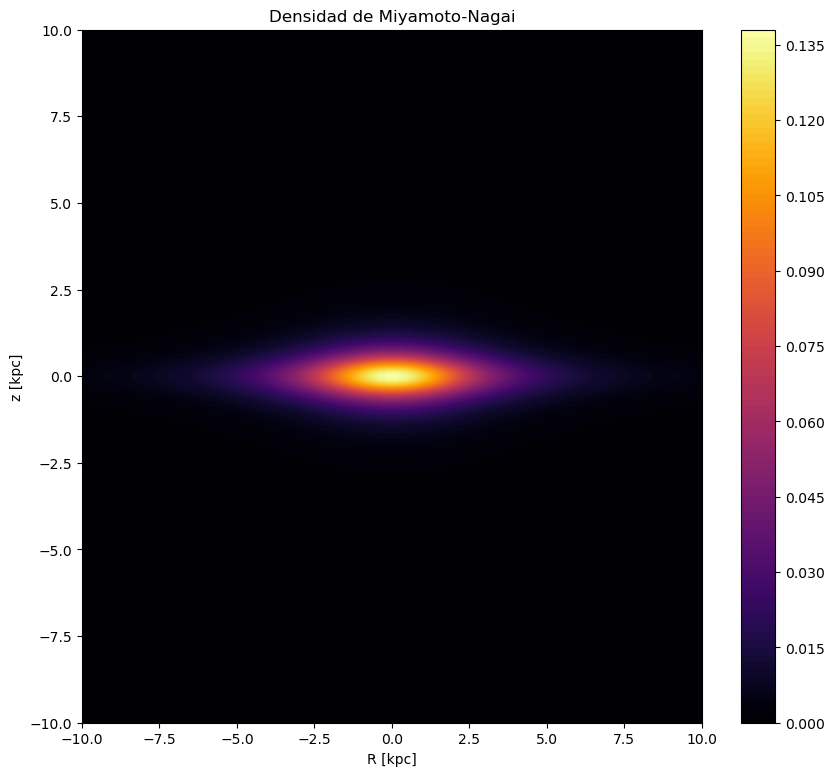

In [70]:
fig, ax = plt.subplots(figsize=(10,9))

CS = ax.contourf(RRp,zzp,rhos,cmap='inferno',levels=100)
#CS2 = ax.contour(CS, levels=CS.levels[::10], colors='r')
cbar = fig.colorbar(CS)
ax.set(xlim=(-10,10),ylim=(-10,10))
ax.set(xlim=(-10,10),ylim=(-10,10),xlabel='R [kpc]',ylabel='z [kpc]',title='Densidad de Miyamoto-Nagai')
plt.savefig('densidad.png')

In [71]:
# frecuencias de epiciclo

def kappa(R):
    return (G*M*(4*(a+b)**2+R**2)/((a+b)**2+R**2)**2.5)**0.5

def nu(R):
    return (G*M*(a+b)/(b*((a+b)**2+R**2)**1.5))**0.5

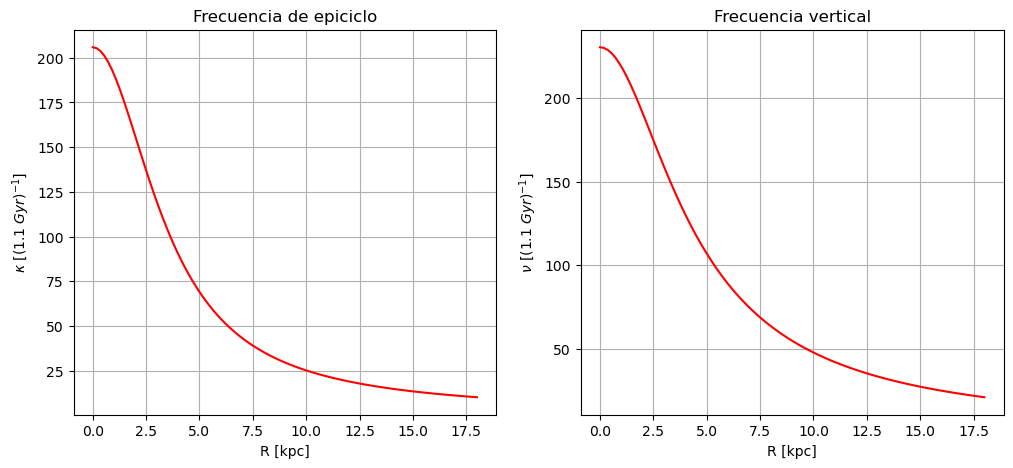

In [72]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

Rs = np.linspace(0,6*a,100)

ax[0].plot(Rs,kappa(Rs),'r')
ax[0].set(title='Frecuencia de epiciclo',xlabel='R [kpc]',ylabel=r'$\kappa$ [(1.1 $Gyr)^{-1}$]')
ax[0].grid()
ax[1].plot(Rs,nu(Rs),'r')
ax[1].set(title='Frecuencia vertical',xlabel='R [kpc]',ylabel=r'$\nu$ [(1.1 $Gyr)^{-1}$]')
ax[1].grid()

plt.savefig('frecuenciasMN.png')

In [73]:
# oscilaciones en cada coordenada

def vert_osc(t,frec,z0,xi):
    return z0*np.cos(frec*t+xi)

def rad_osc(t,Rg,frec,x0,psi):
    return Rg + x0*np.cos(frec*t+psi)
    
def ang_osc(t,phi0,Omega0,Rg,frec,x0,psi):
    return phi0 + Omega0*t - 2*x0/(Rg*frec)*np.sin(frec*t+psi)

def Omega0_MN(Rg):
    return (G*M/((a+b)**2+Rg**2)**1.5)**0.5

In [74]:
Rg1 = 2.5
Rg2 = 10

ts1 = np.linspace(0,4*np.pi/Omega0_MN(Rg1),1000)
ts2 = np.linspace(0,4*np.pi/Omega0_MN(Rg2),1000)
angles = np.linspace(0,2*np.pi,1000)

xs_circ1 = Rg1*np.cos(angles)
ys_circ1 = Rg1*np.sin(angles)
zs_circ1 = np.zeros_like(xs_circ1)

xs_circ2 = Rg2*np.cos(angles)
ys_circ2 = Rg2*np.sin(angles)
zs_circ2 = np.zeros_like(xs_circ1)

R_pert1 = rad_osc(ts1,Rg1,kappa(Rg1),0.5,0)
z_pert1 = vert_osc(ts1,nu(Rg1),0.5,0)
phi_pert1 = ang_osc(ts1,0,Omega0_MN(Rg1),Rg1,kappa(Rg1),0.5,0)

xs_pert1 = R_pert1*np.cos(phi_pert1)
ys_pert1 = R_pert1*np.sin(phi_pert1)

R_pert2 = rad_osc(ts2,Rg2,kappa(Rg2),0.5,0)
z_pert2 = vert_osc(ts2,nu(Rg2),0.5,0)
phi_pert2 = ang_osc(ts2,0,Omega0_MN(Rg2),Rg2,kappa(Rg2),0.5,0)

xs_pert2 = R_pert2*np.cos(phi_pert2)
ys_pert2 = R_pert2*np.sin(phi_pert2)

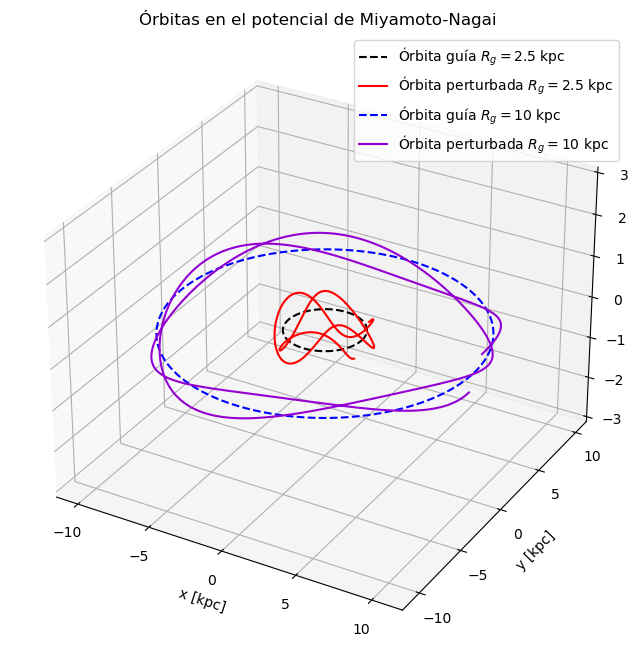

In [75]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.plot(xs_circ1,ys_circ1,zs_circ1,'k--',label=r'Órbita guía $R_g=2.5$ kpc')
ax.plot(xs_pert1,ys_pert1,z_pert1,'r',label=r'Órbita perturbada $R_g=2.5$ kpc')

ax.plot(xs_circ2,ys_circ2,zs_circ2,'b--',label=r'Órbita guía $R_g=10$ kpc')
ax.plot(xs_pert2,ys_pert2,z_pert2,'darkviolet',label=r'Órbita perturbada $R_g=10$ kpc')

ax.set(zlim=(-3,3),title='Órbitas en el potencial de Miyamoto-Nagai',xlabel='x [kpc]',ylabel='y [kpc]',zlabel='z [kpc]')
ax.legend()

plt.savefig('orbitasMN.png')

## 2.

In [76]:
column_names = [
    "ID",
    "Epoca",
    "RA_deg",
    "Dec_deg",
    "Paralaje_arcsec",
    "MovimientoPropio_masyr",
    "Vr_kms",
    "Long_gal_deg",
    "Lat_gal_deg",
    "Dist_metodo1_pc",
    "Dist_metodo2_pc"
]

with gzip.open("subsample_GalEx_2M.txt.gz", "rt") as f:
    df = pd.read_csv(f, sep=",", header=None, names=column_names)

In [77]:
# eliminar estrellas sin datos de velocidad radial
dfp = df.dropna(subset=['Vr_kms'])
dfp

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc
79,5621696888613016960,2016.0,133.258723,-39.523238,0.086473,3.757252,86.660645,261.141288,3.279331,6425.238280,8078.350100
89,6018044850158076672,2016.0,246.194342,-39.188157,3.737517,19.909462,-19.331419,341.727004,7.110754,268.027344,265.727661
113,4334984988063051392,2016.0,256.379667,-10.453017,7.635280,63.811234,7.392281,10.609667,17.909569,130.132538,130.152496
115,5518193949210533760,2016.0,117.748517,-48.672880,1.059334,6.113580,3.339843,262.374617,-11.035135,915.186646,914.578308
153,4353226504442695168,2016.0,249.861028,-5.540419,1.941453,32.428913,-14.634357,11.178116,26.002696,504.268921,504.672821
...,...,...,...,...,...,...,...,...,...,...,...
1999854,201683490904057728,2016.0,75.222381,41.247468,0.617336,5.756928,-12.810690,164.699844,-0.559481,1518.173340,1513.504640
1999865,192584649928439040,2016.0,86.118948,41.025546,2.048161,4.369009,-19.408665,169.528219,6.079631,478.831879,479.001740
1999919,3183088949846923776,2016.0,75.380094,-9.757960,1.155761,3.270247,72.404465,209.233337,-28.816660,839.433716,834.639404
1999947,2105498766434635776,2016.0,286.718939,42.897459,2.224060,10.706657,1.007664,73.614135,15.456009,440.031219,440.226074


In [78]:
# escoge el valor de la distancia del Sol a la estrella

dfp['Dist_pc'] = dfp['Dist_metodo2_pc']
fill = dfp.loc[dfp['Dist_metodo2_pc'].isna(),'Dist_metodo1_pc']
dfp['Dist_pc'] = dfp['Dist_pc'].fillna(fill)

# filtra las estrellas en el vecindario solar

dfp = dfp[dfp['Dist_pc']<1000]
dfp

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\302128525.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Dist_pc'] = dfp['Dist_metodo2_pc']
C:\Users\santi\AppData\Local\Temp\ipykernel_24460\302128525.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Dist_pc'] = dfp['Dist_pc'].fillna(fill)


,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc
89,6018044850158076672,2016.0,246.194342,-39.188157,3.737517,19.909462,-19.331419,341.727004,7.110754,268.027344,265.727661,265.727661
113,4334984988063051392,2016.0,256.379667,-10.453017,7.635280,63.811234,7.392281,10.609667,17.909569,130.132538,130.152496,130.152496
115,5518193949210533760,2016.0,117.748517,-48.672880,1.059334,6.113580,3.339843,262.374617,-11.035135,915.186646,914.578308,914.578308
153,4353226504442695168,2016.0,249.861028,-5.540419,1.941453,32.428913,-14.634357,11.178116,26.002696,504.268921,504.672821,504.672821
178,5258677834621262080,2016.0,154.534866,-57.737682,1.664661,10.645828,31.618607,283.599815,-0.738379,694.151733,729.031677,729.031677
...,...,...,...,...,...,...,...,...,...,...,...,...
1999672,2064126755221359232,2016.0,306.887943,38.358753,1.674632,3.417015,-11.739331,77.191120,-0.068313,586.478394,NaN,586.478394
1999865,192584649928439040,2016.0,86.118948,41.025546,2.048161,4.369009,-19.408665,169.528219,6.079631,478.831879,479.001740,479.001740
1999919,3183088949846923776,2016.0,75.380094,-9.757960,1.155761,3.270247,72.404465,209.233337,-28.816660,839.433716,834.639404,834.639404
1999947,2105498766434635776,2016.0,286.718939,42.897459,2.224060,10.706657,1.007664,73.614135,15.456009,440.031219,440.226074,440.226074


In [79]:
# conversiones

yr = 365.25*24*3600
rad = 180/np.pi*3600*1000
mas = 1/rad
pc = 3.086e+13

# velocidad circular del Sol

v0 = 220.

In [80]:
# cálculo de la velocidad tangencial

dfp['Vt_kms'] = dfp['MovimientoPropio_masyr']*dfp['Dist_pc']*mas/yr*pc

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\1789923227.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Vt_kms'] = dfp['MovimientoPropio_masyr']*dfp['Dist_pc']*mas/yr*pc


In [81]:
# cálculo del ángulo beta

dfp['beta'] = np.arcsin(dfp['Dist_pc']/8000*np.sin(dfp['Long_gal_deg']*np.pi/180))

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\2255609592.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['beta'] = np.arcsin(dfp['Dist_pc']/8000*np.sin(dfp['Long_gal_deg']*np.pi/180))


In [82]:
# Cálculo de la distancia al centro galáctico

dfp['R_pc'] = (dfp['Dist_pc']**2+8000**2-2*dfp['Dist_pc']*8000*np.cos((dfp['Long_gal_deg']%180)*np.pi/180))**0.5

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\4260097947.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['R_pc'] = (dfp['Dist_pc']**2+8000**2-2*dfp['Dist_pc']*8000*np.cos((dfp['Long_gal_deg']%180)*np.pi/180))**0.5


In [83]:
# Velocidad circular

dfp['Vc_kms'] = (dfp['Vr_kms']**2+dfp['Vt_kms']**2)**0.5

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\691804371.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dfp['Vc_kms'] = (dfp['Vr_kms']**2+dfp['Vt_kms']**2)**0.5


In [84]:
dfp = dfp.sort_values(by=['R_pc'])

In [85]:
# filtra las estrellas con beta pequeño

dfp = dfp[np.abs(dfp['beta']) < 0.01]
dfp

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,Vt_kms,beta,R_pc,Vc_kms
412666,4046401939262673152,2016.0,275.692750,-30.709410,0.961949,10.551168,-23.747313,2.385718,-7.897514,997.639221,998.133057,998.133057,49.929335,0.005194,7002.855346,55.288998
584266,4046683212425978880,2016.0,279.266168,-31.369307,0.970744,3.840157,-61.984203,3.149401,-10.937466,993.231689,994.342529,994.342529,18.103051,0.006829,7007.372199,64.573693
87118,3429966006485991296,2016.0,90.529183,26.755705,0.964119,8.156030,-12.247108,183.728043,2.038565,993.742920,990.257996,990.257996,38.290761,-0.008048,7012.133093,40.201667
1503701,945762282595838976,2016.0,106.772953,35.918239,0.979391,8.873695,-1.889955,181.340864,18.462609,982.521179,987.237915,987.237915,41.532985,-0.002888,7013.070466,41.575964
535625,4110021713654018688,2016.0,262.043975,-25.084432,0.969517,4.233960,10.616670,1.172338,5.343199,983.687866,986.757629,986.757629,19.807245,0.002524,7013.477979,22.473109
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018303,950399541605014528,2016.0,103.997714,40.152031,0.967680,7.045881,24.381266,176.359817,17.911009,993.935974,992.853088,992.853088,33.165543,0.007880,8991.070933,41.163083
546630,3448507857041347840,2016.0,85.977371,33.272214,0.964818,12.930982,-52.602165,176.110480,1.952605,991.024414,996.157288,996.157288,61.069765,0.008447,8994.116678,80.600893
1358807,4043617700941843712,2016.0,268.113731,-32.159793,0.980171,7.997265,-41.523006,357.991631,-2.919927,996.007812,996.688660,996.688660,37.789213,-0.004366,8996.144223,56.144319
1880448,899437864853043840,2016.0,113.032414,39.056542,0.963901,0.628842,43.142784,179.832972,24.165326,1000.729920,997.775513,997.775513,2.974685,0.000364,8997.771743,43.245214


In [86]:
def line(x,m,b):
    return m*x+b

In [87]:
# ajuste para la primera constante de Oort

xsA = np.sin(2*np.pi/180*dfp['Long_gal_deg'])*dfp['Dist_pc']/1000
ysA = dfp['Vr_kms']

parsA,covA = curve_fit(line,xsA,ysA)

print(f'A={parsA[0]}±{covA[0,0]**0.5} km/s/kpc')

A=16.43018408419474±9.892243442417625 km/s/kpc


In [88]:
# Cálculo de B=A-Omega0

print(f'B={parsA[0]-v0/8} km/s/kpc')

B=-11.069815915805261 km/s/kpc


In [89]:
df['Dist_pc'] = df['Dist_metodo2_pc']
fill = df.loc[df['Dist_metodo2_pc'].isna(),'Dist_metodo1_pc']
df['Dist_pc'] = df['Dist_pc'].fillna(fill)
df

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc
0,4197265895348110208,2016.0,298.614329,-5.310397,0.530950,6.087040,NaN,35.376319,-16.428341,2735.59546,9693.20996,9693.20996
1,4085039160133824128,2016.0,284.722491,-20.315180,0.082032,5.789214,NaN,15.456506,-10.687023,5718.59326,6293.54443,6293.54443
2,5336002536054942976,2016.0,172.086420,-60.506735,-0.417030,4.400174,NaN,292.875110,0.732370,5777.67480,6193.11865,6193.11865
3,4120694844750771456,2016.0,267.560653,-17.710976,0.204952,9.070207,NaN,10.179022,4.874814,5552.92627,7217.31299,7217.31299
4,4136047634834911488,2016.0,258.889256,-16.397909,1.427181,4.051050,NaN,6.856883,12.599456,5617.32959,4887.94971,4887.94971
...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,5859654397722345984,2016.0,185.375020,-67.208198,-0.080112,8.152262,NaN,300.030601,-4.505247,6602.07617,4993.52686,4993.52686
1999996,6043742086166538240,2016.0,242.374945,-25.183261,0.269193,2.429809,NaN,349.720317,19.200180,4228.62109,3699.43213,3699.43213
1999997,5966065236101431808,2016.0,257.765590,-40.907259,0.800141,3.859567,NaN,346.127998,-0.763886,4447.78076,6635.56104,6635.56104
1999998,4533207624393483904,2016.0,283.501211,23.197747,0.155786,2.933200,NaN,54.065394,9.814135,4166.23438,5009.70166,5009.70166


In [90]:
df['x'] = df['Dist_pc']*np.cos(df['Long_gal_deg']*np.pi/180)*np.cos(df['Lat_gal_deg']*np.pi/180)
df['y'] = df['Dist_pc']*np.sin(df['Long_gal_deg']*np.pi/180)*np.cos(df['Lat_gal_deg']*np.pi/180)
df['z'] = df['Dist_pc']*np.sin(df['Lat_gal_deg']*np.pi/180)
df

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,x,y,z
0,4197265895348110208,2016.0,298.614329,-5.310397,0.530950,6.087040,NaN,35.376319,-16.428341,2735.59546,9693.20996,9693.20996,7580.857227,5382.720494,-2741.394373
1,4085039160133824128,2016.0,284.722491,-20.315180,0.082032,5.789214,NaN,15.456506,-10.687023,5718.59326,6293.54443,6293.54443,5960.711507,1648.179771,-1167.100366
2,5336002536054942976,2016.0,172.086420,-60.506735,-0.417030,4.400174,NaN,292.875110,0.732370,5777.67480,6193.11865,6193.11865,2407.215585,-5705.590719,79.159899
3,4120694844750771456,2016.0,267.560653,-17.710976,0.204952,9.070207,NaN,10.179022,4.874814,5552.92627,7217.31299,7217.31299,7078.019280,1270.861508,613.319573
4,4136047634834911488,2016.0,258.889256,-16.397909,1.427181,4.051050,NaN,6.856883,12.599456,5617.32959,4887.94971,4887.94971,4736.122865,569.517873,1066.227914
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1999995,5859654397722345984,2016.0,185.375020,-67.208198,-0.080112,8.152262,NaN,300.030601,-4.505247,6602.07617,4993.52686,4993.52686,2491.350938,-4309.829002,-392.243520
1999996,6043742086166538240,2016.0,242.374945,-25.183261,0.269193,2.429809,NaN,349.720317,19.200180,4228.62109,3699.43213,3699.43213,3437.573674,-623.453892,1216.630826
1999997,5966065236101431808,2016.0,257.765590,-40.907259,0.800141,3.859567,NaN,346.127998,-0.763886,4447.78076,6635.56104,6635.56104,6441.454120,-1590.758661,-88.464805
1999998,4533207624393483904,2016.0,283.501211,23.197747,0.155786,2.933200,NaN,54.065394,9.814135,4166.23438,5009.70166,5009.70166,2896.976693,3996.931708,853.916674


In [91]:
dfp['x'] = dfp['Dist_pc']*np.cos(dfp['Long_gal_deg']*np.pi/180)*np.cos(dfp['Lat_gal_deg']*np.pi/180)
dfp['y'] = dfp['Dist_pc']*np.sin(dfp['Long_gal_deg']*np.pi/180)*np.cos(dfp['Lat_gal_deg']*np.pi/180)
dfp['z'] = dfp['Dist_pc']*np.sin(dfp['Lat_gal_deg']*np.pi/180)
dfp

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,Vt_kms,beta,R_pc,Vc_kms,x,y,z
412666,4046401939262673152,2016.0,275.692750,-30.709410,0.961949,10.551168,-23.747313,2.385718,-7.897514,997.639221,998.133057,998.133057,49.929335,0.005194,7002.855346,55.288998,987.809252,41.154808,-137.145045
584266,4046683212425978880,2016.0,279.266168,-31.369307,0.970744,3.840157,-61.984203,3.149401,-10.937466,993.231689,994.342529,994.342529,18.103051,0.006829,7007.372199,64.573693,974.805646,53.636571,-188.664084
87118,3429966006485991296,2016.0,90.529183,26.755705,0.964119,8.156030,-12.247108,183.728043,2.038565,993.742920,990.257996,990.257996,38.290761,-0.008048,7012.133093,40.201667,-987.537126,-64.346549,35.225619
1503701,945762282595838976,2016.0,106.772953,35.918239,0.979391,8.873695,-1.889955,181.340864,18.462609,982.521179,987.237915,987.237915,41.532985,-0.002888,7013.070466,41.575964,-936.168880,-21.912684,312.644148
535625,4110021713654018688,2016.0,262.043975,-25.084432,0.969517,4.233960,10.616670,1.172338,5.343199,983.687866,986.757629,986.757629,19.807245,0.002524,7013.477979,22.473109,982.264288,20.101076,91.888158
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018303,950399541605014528,2016.0,103.997714,40.152031,0.967680,7.045881,24.381266,176.359817,17.911009,993.935974,992.853088,992.853088,33.165543,0.007880,8991.070933,41.163083,-942.828737,59.981631,305.341498
546630,3448507857041347840,2016.0,85.977371,33.272214,0.964818,12.930982,-52.602165,176.110480,1.952605,991.024414,996.157288,996.157288,61.069765,0.008447,8994.116678,80.600893,-993.285759,67.532903,33.941861
1358807,4043617700941843712,2016.0,268.113731,-32.159793,0.980171,7.997265,-41.523006,357.991631,-2.919927,996.007812,996.688660,996.688660,37.789213,-0.004366,8996.144223,56.144319,994.783208,-34.884078,-50.771601
1880448,899437864853043840,2016.0,113.032414,39.056542,0.963901,0.628842,43.142784,179.832972,24.165326,1000.729920,997.775513,997.775513,2.974685,0.000364,8997.771743,43.245214,-910.334607,2.653807,408.460322


In [92]:
dfp['R_pc'] = ((dfp['x']-8000)**2+dfp['y']**2+dfp['z']**2)**0.5
dfp['Rdisk_pc'] = ((dfp['x']-8000)**2+dfp['y']**2)**0.5
dfp

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,Vt_kms,beta,R_pc,Vc_kms,x,y,z,Rdisk_pc
412666,4046401939262673152,2016.0,275.692750,-30.709410,0.961949,10.551168,-23.747313,2.385718,-7.897514,997.639221,998.133057,998.133057,49.929335,0.005194,7013.652513,55.288998,987.809252,41.154808,-137.145045,7012.311517
584266,4046683212425978880,2016.0,279.266168,-31.369307,0.970744,3.840157,-61.984203,3.149401,-10.937466,993.231689,994.342529,994.342529,18.103051,0.006829,7027.931896,64.573693,974.805646,53.636571,-188.664084,7025.399106
87118,3429966006485991296,2016.0,90.529183,26.755705,0.964119,8.156030,-12.247108,183.728043,2.038565,993.742920,990.257996,990.257996,38.290761,-0.008048,8987.836498,40.201667,-987.537126,-64.346549,35.225619,8987.767469
1503701,945762282595838976,2016.0,106.772953,35.918239,0.979391,8.873695,-1.889955,181.340864,18.462609,982.521179,987.237915,987.237915,41.532985,-0.002888,8941.663200,41.575964,-936.168880,-21.912684,312.644148,8936.195746
535625,4110021713654018688,2016.0,262.043975,-25.084432,0.969517,4.233960,10.616670,1.172338,5.343199,983.687866,986.757629,986.757629,19.807245,0.002524,7018.366050,22.473109,982.264288,20.101076,91.888158,7017.764500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1018303,950399541605014528,2016.0,103.997714,40.152031,0.967680,7.045881,24.381266,176.359817,17.911009,993.935974,992.853088,992.853088,33.165543,0.007880,8948.241003,41.163083,-942.828737,59.981631,305.341498,8943.029890
546630,3448507857041347840,2016.0,85.977371,33.272214,0.964818,12.930982,-52.602165,176.110480,1.952605,991.024414,996.157288,996.157288,61.069765,0.008447,8993.603365,80.600893,-993.285759,67.532903,33.941861,8993.539317
1358807,4043617700941843712,2016.0,268.113731,-32.159793,0.980171,7.997265,-41.523006,357.991631,-2.919927,996.007812,996.688660,996.688660,37.789213,-0.004366,7005.487632,56.144319,994.783208,-34.884078,-50.771601,7005.303648
1880448,899437864853043840,2016.0,113.032414,39.056542,0.963901,0.628842,43.142784,179.832972,24.165326,1000.729920,997.775513,997.775513,2.974685,0.000364,8919.692242,43.245214,-910.334607,2.653807,408.460322,8910.335002


In [93]:
df = df.dropna(subset=['Vr_kms'])
df['R_pc'] = ((df['x']-8000)**2+df['y']**2+df['z']**2)**0.5
df['Rdisk_pc'] = ((df['x']-8000)**2+df['y']**2)**0.5
df['Vt_kms'] = df['MovimientoPropio_masyr']*df['Dist_pc']*mas/yr*pc
df['Vc_kms'] = (df['Vr_kms']**2+df['Vt_kms']**2)**0.5
df = df.sort_values(by=['Rdisk_pc'])
#df = df[(df['z'] > -1000) & (df['z'] < 1000)]
df

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\129409570.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['R_pc'] = ((df['x']-8000)**2+df['y']**2+df['z']**2)**0.5
C:\Users\santi\AppData\Local\Temp\ipykernel_24460\129409570.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Rdisk_pc'] = ((df['x']-8000)**2+df['y']**2)**0.5
C:\Users\santi\AppData\Local\Temp\ipykernel_24460\129409570.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[ro

,ID,Epoca,RA_deg,Dec_deg,Paralaje_arcsec,MovimientoPropio_masyr,Vr_kms,Long_gal_deg,Lat_gal_deg,Dist_metodo1_pc,Dist_metodo2_pc,Dist_pc,x,y,z,R_pc,Rdisk_pc,Vt_kms,Vc_kms
160822,4110664859229615488,2016.0,260.250348,-25.711075,0.073383,6.761144,79.220160,359.743133,6.341441,7401.81885,8046.02979,8046.02979,7996.718404,-35.850991,888.709655,889.438538,36.000867,257.910274,269.802786
363561,4045578920449171072,2016.0,274.798731,-32.898428,0.058408,8.246676,-0.404371,0.067566,-8.214796,8619.02148,8023.11426,8023.11426,7940.786503,9.364232,-1146.378846,1147.945289,59.949371,313.681373,313.681634
514458,4110759314155569280,2016.0,259.776333,-25.158438,0.045845,7.382292,125.434820,359.959513,7.006619,8447.35742,7984.10596,7984.10596,7924.479209,-5.599709,973.933209,976.872890,75.728110,279.437283,306.299020
1122381,6735023811300273536,2016.0,278.344648,-33.699188,0.065146,2.067889,65.822700,0.664302,-11.227762,8682.25781,8114.91406,8114.91406,7959.067133,92.283653,-1580.051994,1583.273848,100.954308,79.556910,103.256621
1410814,4049048055781380352,2016.0,272.175897,-31.522972,0.061591,7.511162,31.923440,0.250561,-5.610414,7464.21680,8147.66406,8147.66406,8108.556342,35.459929,-796.546473,804.691350,114.201076,290.139649,291.890600
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
390362,4660168610041319680,2016.0,83.158990,-66.905097,0.014897,1.741441,304.427500,276.967590,-32.488018,22310.62700,22556.61720,22556.61720,2308.075618,-18886.079474,-12115.682752,23148.904286,19725.161623,186.229984,356.872120
181003,4661387178167183232,2016.0,76.886321,-68.279707,-0.054164,2.089139,271.130000,279.091744,-34.600728,20937.06250,25904.80860,25904.80860,3369.371224,-21055.113336,-14710.154607,26098.834629,21558.305139,256.575123,373.285776
1172542,4660167884143427584,2016.0,83.132449,-66.983780,0.026469,1.767382,312.346440,277.061671,-32.489232,27260.66410,24929.75980,24929.75980,2585.139772,-20868.552807,-13390.798325,25379.729852,21559.619838,208.888867,375.759041
533235,4661349245024212224,2016.0,75.258560,-68.421716,-0.052124,1.837076,266.296780,279.441901,-35.146844,16772.40230,26256.41600,26256.41600,3521.987706,-21178.471868,-15115.135232,26401.658620,21646.714873,228.680585,351.011090


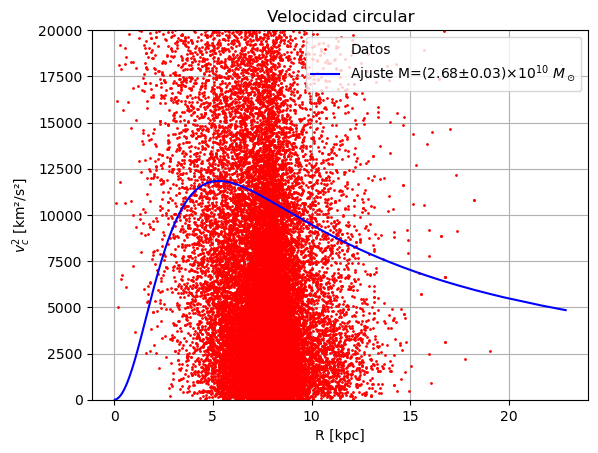

In [94]:
# estimación de la masa de estrellas

fig = plt.figure()
ax = fig.add_subplot()

def vc_MN(R,mass):
    return G*mass*R**2/((a+b)**2+R**2)**1.5

mass_fit, cov_mass = curve_fit(vc_MN,df['Rdisk_pc']/1000,df['Vc_kms']**2)

ax.plot(df['Rdisk_pc']/1000, df['Vc_kms']**2, 'r.',markersize=2,label='Datos')
ax.plot(df['Rdisk_pc']/1000, vc_MN(df['Rdisk_pc']/1000,mass_fit), 'b',label=r'Ajuste M=(%.2f±%.2f)$\times 10^{10}~M_\odot$'%(mass_fit,cov_mass**0.5))
ax.set(title='Velocidad circular',xlabel='R [kpc]',ylabel=r'$v_c^2$ [km²/s²]',ylim=(0,20000))
ax.legend()
ax.grid()
plt.savefig('ajusteMW.png')

## 3.

In [95]:
# Parámetros para el perfil de Hernquist

Mh = 120 # 10^10 M_sun
alpha = 50

In [96]:
# correcciones a las frecuencias por la presencia del halo

def kappa_corr(R):
    return (G*M*(4*(a+b)**2+R**2)/((a+b)**2+R**2)**2.5+G*Mh*(R+3*alpha)/(R*(R+alpha)**3))**0.5

def nu_corr(R):
    return (G*M*(a+b)/(b*((a+b)**2+R**2)**1.5)+G*Mh/(R*(R+alpha)**2))**0.5

C:\Users\santi\AppData\Local\Temp\ipykernel_24460\8179793.py:4: RuntimeWarning: divide by zero encountered in divide
  return (G*M*(4*(a+b)**2+R**2)/((a+b)**2+R**2)**2.5+G*Mh*(R+3*alpha)/(R*(R+alpha)**3))**0.5
C:\Users\santi\AppData\Local\Temp\ipykernel_24460\8179793.py:7: RuntimeWarning: divide by zero encountered in divide
  return (G*M*(a+b)/(b*((a+b)**2+R**2)**1.5)+G*Mh/(R*(R+alpha)**2))**0.5


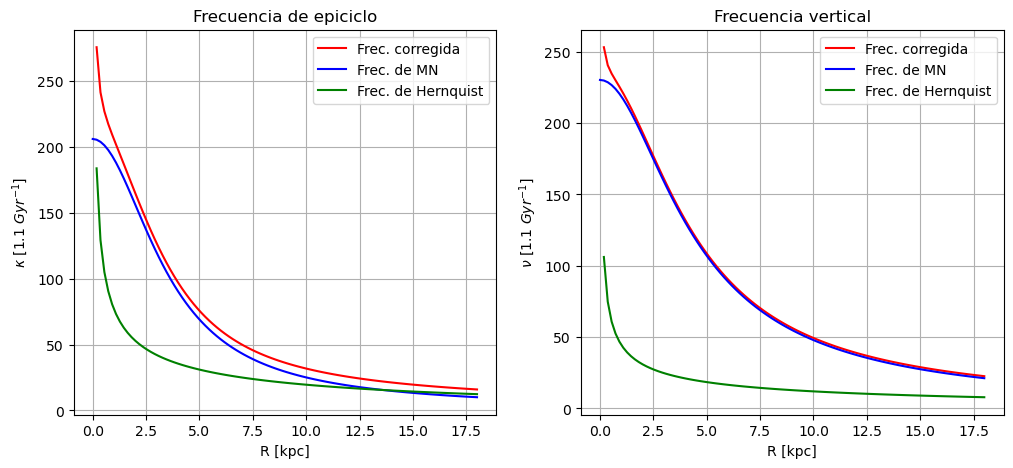

In [97]:
fig, ax = plt.subplots(1,2,figsize=(12,5))

Rs = np.linspace(0,6*a,100)

ax[0].plot(Rs,kappa_corr(Rs),'r',label='Frec. corregida')
ax[0].plot(Rs,kappa(Rs),'b',label='Frec. de MN')
ax[0].plot(Rs,(kappa_corr(Rs)**2-kappa(Rs)**2)**0.5,'g',label='Frec. de Hernquist')
ax[0].set(title='Frecuencia de epiciclo',xlabel='R [kpc]',ylabel=r'$\kappa$ [1.1 $Gyr^{-1}$]')
ax[0].grid()
ax[0].legend()
ax[1].plot(Rs,nu_corr(Rs),'r',label='Frec. corregida')
ax[1].plot(Rs,nu(Rs),'b',label='Frec. de MN')
ax[1].plot(Rs,(nu_corr(Rs)**2-nu(Rs)**2)**0.5,'g',label='Frec. de Hernquist')
ax[1].set(title='Frecuencia vertical',xlabel='R [kpc]',ylabel=r'$\nu$ [1.1 $Gyr^{-1}$]')
ax[1].grid()
ax[1].legend()

plt.savefig('frecuenciascorregidas.png')

In [98]:
def Omega0_corr(Rg):
    return (G*M/((a+b)**2+Rg**2)**1.5+G*Mh/(Rg*(Rg+alpha))**2)**0.5

In [99]:
Rg1 = 2.5
Rg2 = 10

ts1 = np.linspace(0,4*np.pi/Omega0_corr(Rg1),1000)
ts2 = np.linspace(0,4*np.pi/Omega0_corr(Rg2),1000)

R_pert1c = rad_osc(ts1,Rg1,kappa_corr(Rg1),0.5,0)
z_pert1c = vert_osc(ts1,nu_corr(Rg1),0.5,0)
phi_pert1c = ang_osc(ts1,0,Omega0_corr(Rg1),Rg1,kappa_corr(Rg1),0.5,0)

xs_pert1c = R_pert1c*np.cos(phi_pert1c)
ys_pert1c = R_pert1c*np.sin(phi_pert1c)

R_pert2c = rad_osc(ts2,Rg2,kappa_corr(Rg2),0.5,0)
z_pert2c = vert_osc(ts2,nu_corr(Rg2),0.5,0)
phi_pert2c = ang_osc(ts2,0,Omega0_corr(Rg2),Rg2,kappa_corr(Rg2),0.5,0)

xs_pert2c = R_pert2*np.cos(phi_pert2c)
ys_pert2c = R_pert2*np.sin(phi_pert2c)

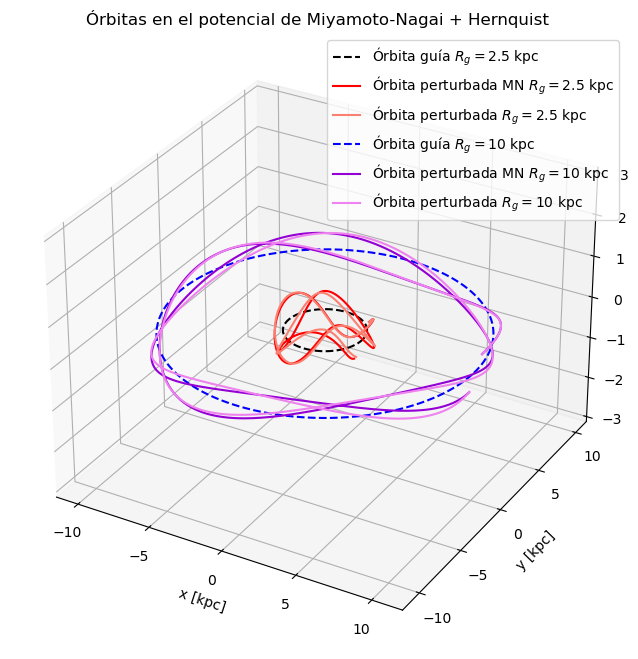

In [100]:
fig = plt.figure(figsize=(8,8))
ax = fig.add_subplot(projection='3d')

ax.plot(xs_circ1,ys_circ1,zs_circ1,'k--',label=r'Órbita guía $R_g=2.5$ kpc')
ax.plot(xs_pert1,ys_pert1,z_pert1,'r',label=r'Órbita perturbada MN $R_g=2.5$ kpc')
ax.plot(xs_pert1c,ys_pert1c,z_pert1c,'salmon',label=r'Órbita perturbada $R_g=2.5$ kpc')

ax.plot(xs_circ2,ys_circ2,zs_circ2,'b--',label=r'Órbita guía $R_g=10$ kpc')
ax.plot(xs_pert2,ys_pert2,z_pert2,'darkviolet',label=r'Órbita perturbada MN $R_g=10$ kpc')
ax.plot(xs_pert2c,ys_pert2c,z_pert2c,'violet',label=r'Órbita perturbada $R_g=10$ kpc')

ax.set(zlim=(-3,3),title='Órbitas en el potencial de Miyamoto-Nagai + Hernquist',xlabel='x [kpc]',ylabel='y [kpc]',zlabel='z [kpc]')
ax.legend()

plt.savefig('orbitascorregidas.png')

In [101]:
# curva de rotación con el halo

def vc_corr(R,halo,alpha):
    return (G*R*(mass_fit*R/((a+b)**2+R**2)**1.5+halo/(R+alpha)**2))

In [102]:
# ajuste (se concluye que no se puede)

masses_fit, cov_masses = curve_fit(vc_corr,df['Rdisk_pc']/1000,df['Vc_kms']**2)
masses_fit

array([0.95874304, 0.06669279])

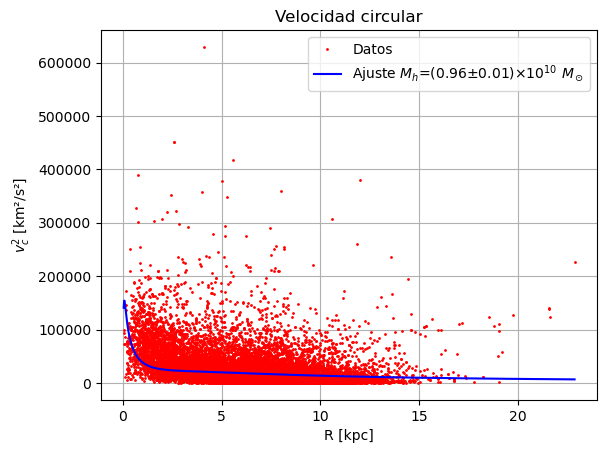

In [103]:
fig = plt.figure()
ax = fig.add_subplot()

ax.plot(df['Rdisk_pc']/1000, df['Vc_kms']**2, 'r.',markersize=2,label='Datos')
ax.plot(df['Rdisk_pc']/1000, vc_corr(df['Rdisk_pc']/1000,*masses_fit), 'b',label=r'Ajuste $M_h$=(%.2f±%.2f)$\times 10^{10}~M_\odot$'%(masses_fit[0],cov_masses[0,0]**0.5))
ax.set(title='Velocidad circular',xlabel='R [kpc]',ylabel=r'$v_c^2$ [km²/s²]')
ax.legend()
ax.grid()
plt.savefig('ajusteMWhalo.png')

In [104]:
masses_fit[1],cov_masses[1,1]**0.5

(0.06669278638405794, 0.0036736538695885212)